# %% [markdown]
# # 🏷️ Enriched Label Variations — Model Comparison
#
# Three target definitions derived from `status_enriched`:
#
# | Target | Strategy | Rows | Classes |
# |--------|----------|------|---------|
# | **target_bin_acq_oper_vs_closed** | acquired + operating → 1, closed → 0, drop unknown | 43,212 | Binary |
# | **target_bin_acq_vs_closed** | acquired → 1, closed → 0, drop operating + unknown | 13,850 | Binary |
# | **target_multiclass** | closed=0, operating=1, acquired=2, drop unknown | 43,212 | 3-class |
#
# Models tested:
# 1. Logistic Regression (balanced)
# 2. Decision Tree (balanced)
# 3. Random Forest (balanced)
# 4. KNN (k=5)
# 5. Gradient Boosting
# 6. XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
print('✅ All imports loaded')

✅ All imports loaded


In [2]:
# ## 2 · Load Data

df = pd.read_csv('../raw_data/features_enriched_with_targets_full.csv')
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nstatus_enriched distribution:')
print(df['status_enriched'].value_counts())
df.head(3)

Dataset: 44,363 rows × 37 columns

status_enriched distribution:
status_enriched
operating    29362
closed       11031
acquired      2819
unknown       1151
Name: count, dtype: int64


,permalink,category_list,market,funding_total_usd,country_code,state_code,region,funding_rounds,founded_at,first_funding_at,...,avg_years_between_rounds,region_group,market_clean,industry_group,years_operating,target_bin_acq_oper_vs_closed,target_bin_acq_vs_closed,target_multiclass,target_bin_refined,industry_median_funding
0,/organization/waywire,|entertainment|politics|social media|news|,news,1750000.0,usa,ny,new york city,1.0,2012-06-01,2012-06-30,...,1.040383,USA,news,Consumer_Internet,13.796030,1.0,1.0,2.0,1.0,500000.0
1,/organization/tv-communications,|games|,games,4000000.0,usa,ca,los angeles,2.0,2010-02-01,2010-06-04,...,0.303901,USA,games,Consumer_Internet,16.125941,1.0,NaN,1.0,1.0,500000.0
2,/organization/rock-your-paper,|publishing|education|,publishing,40000.0,est,unknown,tallinn,1.0,2012-10-26,2012-08-09,...,1.040383,EU_UK,publishing,Other,13.393566,1.0,NaN,1.0,1.0,717347.5


In [3]:
# ## 3 · Feature Definition

num_features = [
    'funding_total_usd', 'funding_rounds',
    'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity',
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E',
    'avg_raised_per_round', 'age_first_funding_days',
    'has_multiple_rounds', 'funding_span_days', 'avg_years_between_rounds',
    'years_operating'
]

cat_features = ['region_group', 'industry_group']

print(f'Numerical features:  {len(num_features)}')
print(f'Categorical features: {len(cat_features)}')

#
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)
print('✅ Preprocessor defined')

Numerical features:  19
Categorical features: 2
✅ Preprocessor defined



--- bin_acq_oper_vs_closed (Binary: (acquired+operating) vs closed) ---
  Rows: 43,212
  Distribution: {0.0: 11031, 1.0: 32181}

--- bin_acq_vs_closed (Binary: acquired vs closed (operating dropped)) ---
  Rows: 13,850
  Distribution: {0.0: 11031, 1.0: 2819}

--- multiclass (3-class: closed(0) / operating(1) / acquired(2)) ---
  Rows: 43,212
  Distribution: {0.0: 11031, 1.0: 29362, 2.0: 2819}

--- target_bin_refined (Binary: (acquired+operating) vs closed but refined with business logic) ---
  Rows: 43,212
  Distribution: {0.0: 11031, 1.0: 32181}


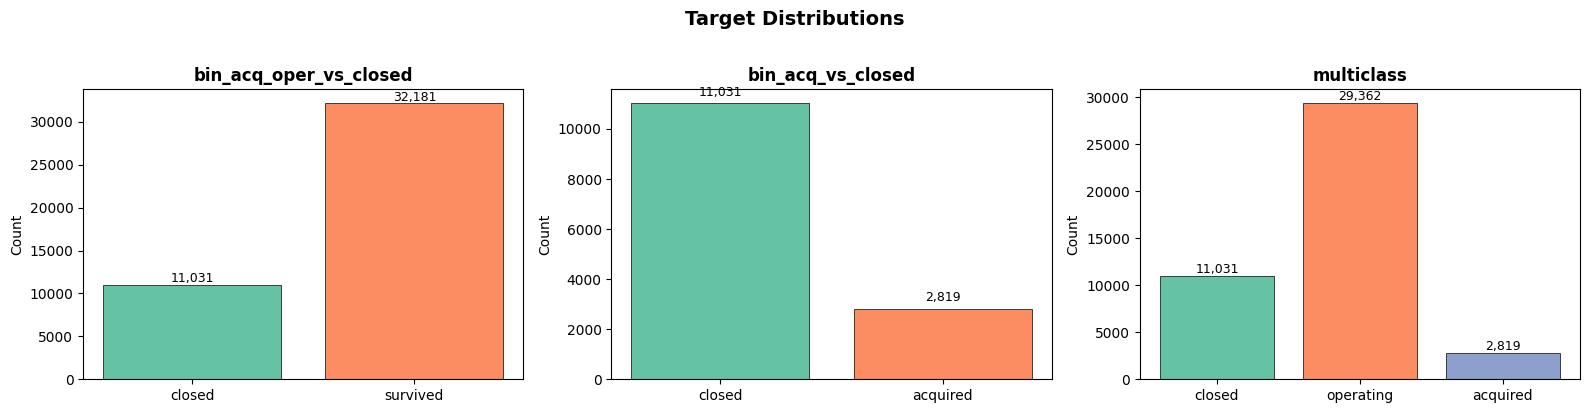

✅ 6 models defined


In [4]:
# ## 4 · Define Targets & Models

#
TARGETS = {
    'bin_acq_oper_vs_closed': {
        'col': 'target_bin_acq_oper_vs_closed',
        'desc': 'Binary: (acquired+operating) vs closed',
        'labels': {0: 'closed', 1: 'survived'},
    },
    'bin_acq_vs_closed': {
        'col': 'target_bin_acq_vs_closed',
        'desc': 'Binary: acquired vs closed (operating dropped)',
        'labels': {0: 'closed', 1: 'acquired'},
    },
    'multiclass': {
        'col': 'target_multiclass',
        'desc': '3-class: closed(0) / operating(1) / acquired(2)',
        'labels': {0: 'closed', 1: 'operating', 2: 'acquired'},
    },
    'target_bin_refined': {
        'col': 'target_bin_refined',
        'desc': 'Binary: (acquired+operating) vs closed but refined with business logic',
        'labels': {0: 'closed', 1: 'survived'},
    },
}

for name, t in TARGETS.items():
    valid = df[t['col']].dropna()
    print(f"\n--- {name} ({t['desc']}) ---")
    print(f"  Rows: {len(valid):,}")
    print(f"  Distribution: {valid.value_counts().sort_index().to_dict()}")

#
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette('Set2')

for ax, (name, t) in zip(axes, TARGETS.items()):
    valid = df[t['col']].dropna()
    counts = valid.value_counts().sort_index()
    label_names = [t['labels'][int(k)] for k in counts.index]
    bars = ax.bar(label_names, counts.values, color=palette[:len(counts)], edgecolor='black', linewidth=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 300, f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Target Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#
def get_models():
    """Return fresh model instances (must be called per target to avoid refitting)."""
    return {
        'LogReg (balanced)': LogisticRegression(class_weight='balanced', max_iter=1000),
        'Decision Tree (balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        'Random Forest (balanced)': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=SEED),
        'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
        'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=SEED, use_label_encoder=False),
    }

print(f'✅ {len(get_models())} models defined')


In [5]:
# ## 5 · Train/Test Splits

#
splits = {}

for name, t in TARGETS.items():
    mask = df[t['col']].notna()
    data = df[mask]

    X = data[num_features + cat_features]
    y = data[t['col']].astype(int).values
    n_classes = len(t['labels'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    splits[name] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'n_classes': n_classes,
        'label_names': [t['labels'][i] for i in range(n_classes)],
    }

    print(f'{name}: train={len(X_train):,} | test={len(X_test):,} | classes={n_classes} {splits[name]["label_names"]}')

bin_acq_oper_vs_closed: train=34,569 | test=8,643 | classes=2 ['closed', 'survived']
bin_acq_vs_closed: train=11,080 | test=2,770 | classes=2 ['closed', 'acquired']
multiclass: train=34,569 | test=8,643 | classes=3 ['closed', 'operating', 'acquired']
target_bin_refined: train=34,569 | test=8,643 | classes=2 ['closed', 'survived']


In [6]:
# ## 6 · Evaluation Helper

#
def evaluate_model(model, X_test, y_test, n_classes):
    """Predict and compute metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    try:
        if n_classes == 2:
            roc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        roc = np.nan

    return y_pred, y_proba, {
        'accuracy': acc,
        'f1_weighted': f1_w,
        'f1_macro': f1_m,
        'roc_auc': roc
    }


  TARGET: bin_acq_oper_vs_closed  (Binary: (acquired+operating) vs closed)

  🔹 LogReg (balanced) ... Acc=0.5645  F1w=0.5924  F1m=0.5342  ROC=0.6155

  🔹 Decision Tree (balanced) ... Acc=0.6278  F1w=0.6315  F1m=0.5204  ROC=0.5204

  🔹 Random Forest (balanced) ... Acc=0.7199  F1w=0.6679  F1m=0.5119  ROC=0.5766

  🔹 KNN (k=5) ... Acc=0.7000  F1w=0.6668  F1m=0.5265  ROC=0.5561

  🔹 Gradient Boosting ... Acc=0.7448  F1w=0.6428  F1m=0.4411  ROC=0.6280

  🔹 XGBoost ... Acc=0.7353  F1w=0.6535  F1m=0.4700  ROC=0.6044

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION REPORTS
──────────────────────────────────────────────────────────────────────

  📋 LogReg (balanced):
              precision    recall  f1-score   support

      closed       0.32      0.61      0.42      2206
    survived       0.80      0.55      0.65      6437

    accuracy                           0.56      8643
   macro avg       0.56      0.58      0.53      8643
weighted avg       0

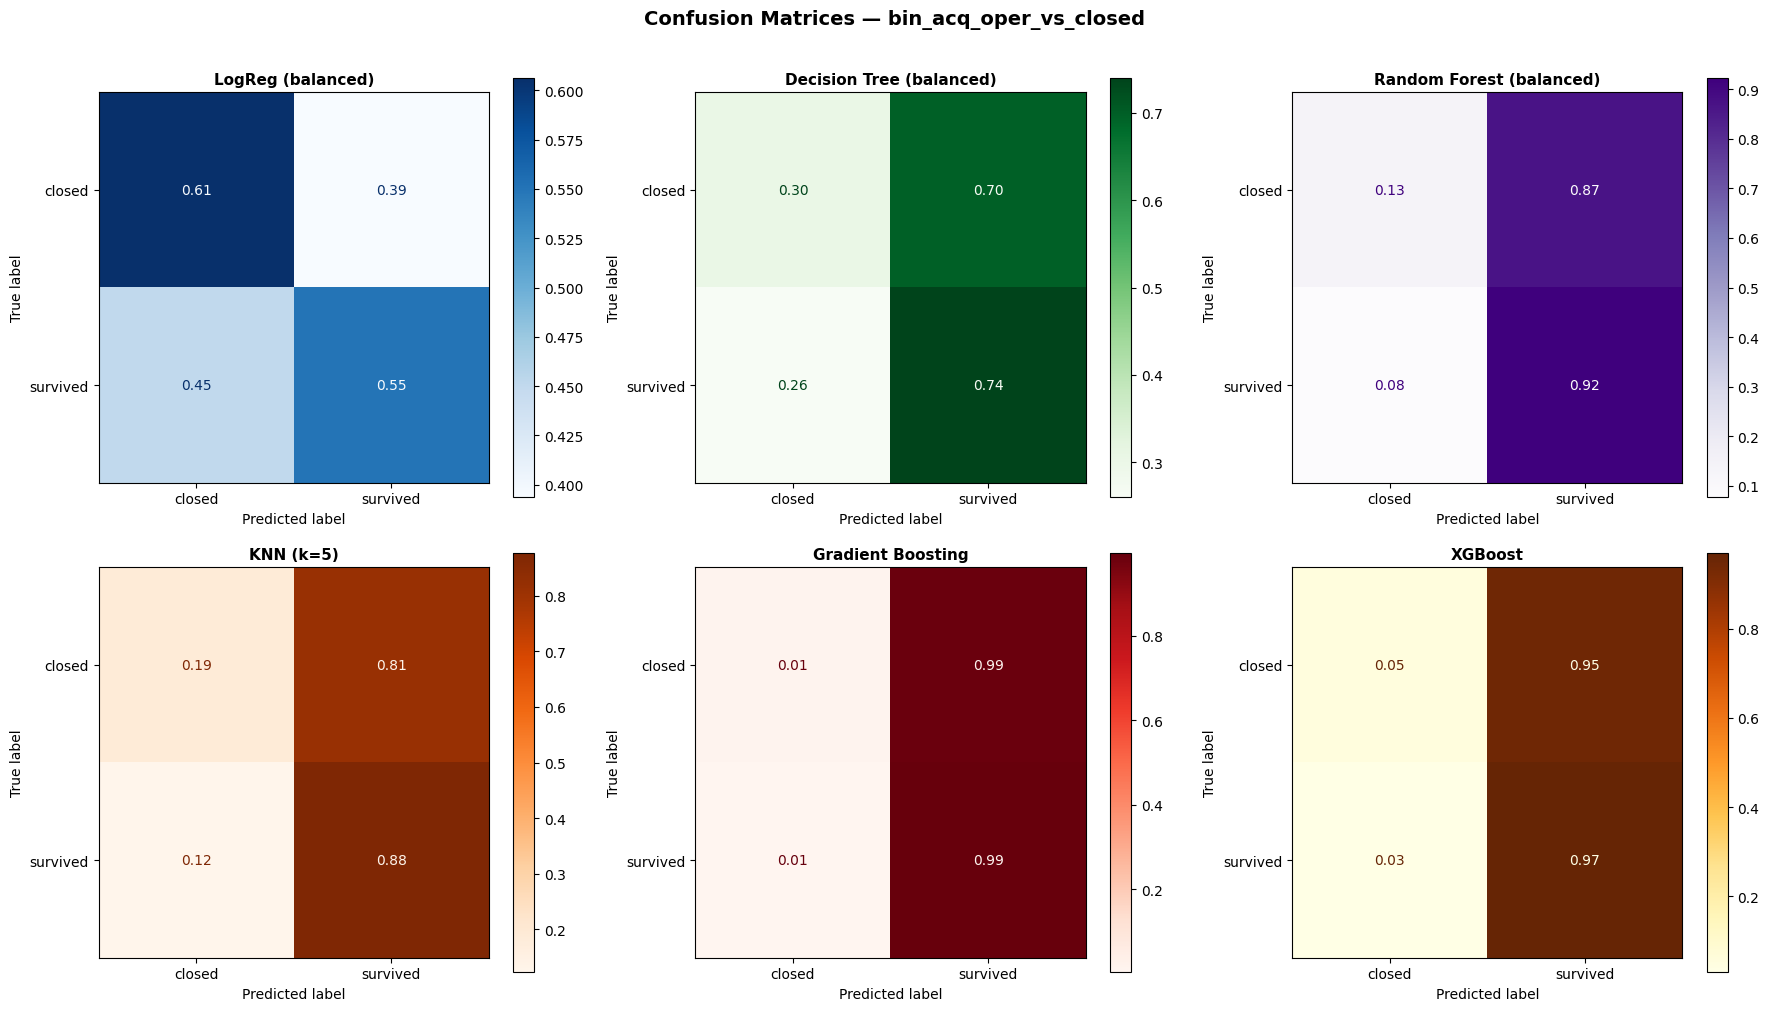


  TARGET: bin_acq_vs_closed  (Binary: acquired vs closed (operating dropped))

  🔹 LogReg (balanced) ... Acc=0.7245  F1w=0.7473  F1m=0.6576  ROC=0.7881

  🔹 Decision Tree (balanced) ... Acc=0.7567  F1w=0.7575  F1m=0.6273  ROC=0.6286

  🔹 Random Forest (balanced) ... Acc=0.8076  F1w=0.7812  F1m=0.6279  ROC=0.7834

  🔹 KNN (k=5) ... Acc=0.7884  F1w=0.7759  F1m=0.6368  ROC=0.7169

  🔹 Gradient Boosting ... Acc=0.8238  F1w=0.7978  F1m=0.6542  ROC=0.8088

  🔹 XGBoost ... Acc=0.8083  F1w=0.7917  F1m=0.6560  ROC=0.7985

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION REPORTS
──────────────────────────────────────────────────────────────────────

  📋 LogReg (balanced):
              precision    recall  f1-score   support

      closed       0.90      0.73      0.81      2206
    acquired       0.40      0.69      0.51       564

    accuracy                           0.72      2770
   macro avg       0.65      0.71      0.66      2770
weighted avg     

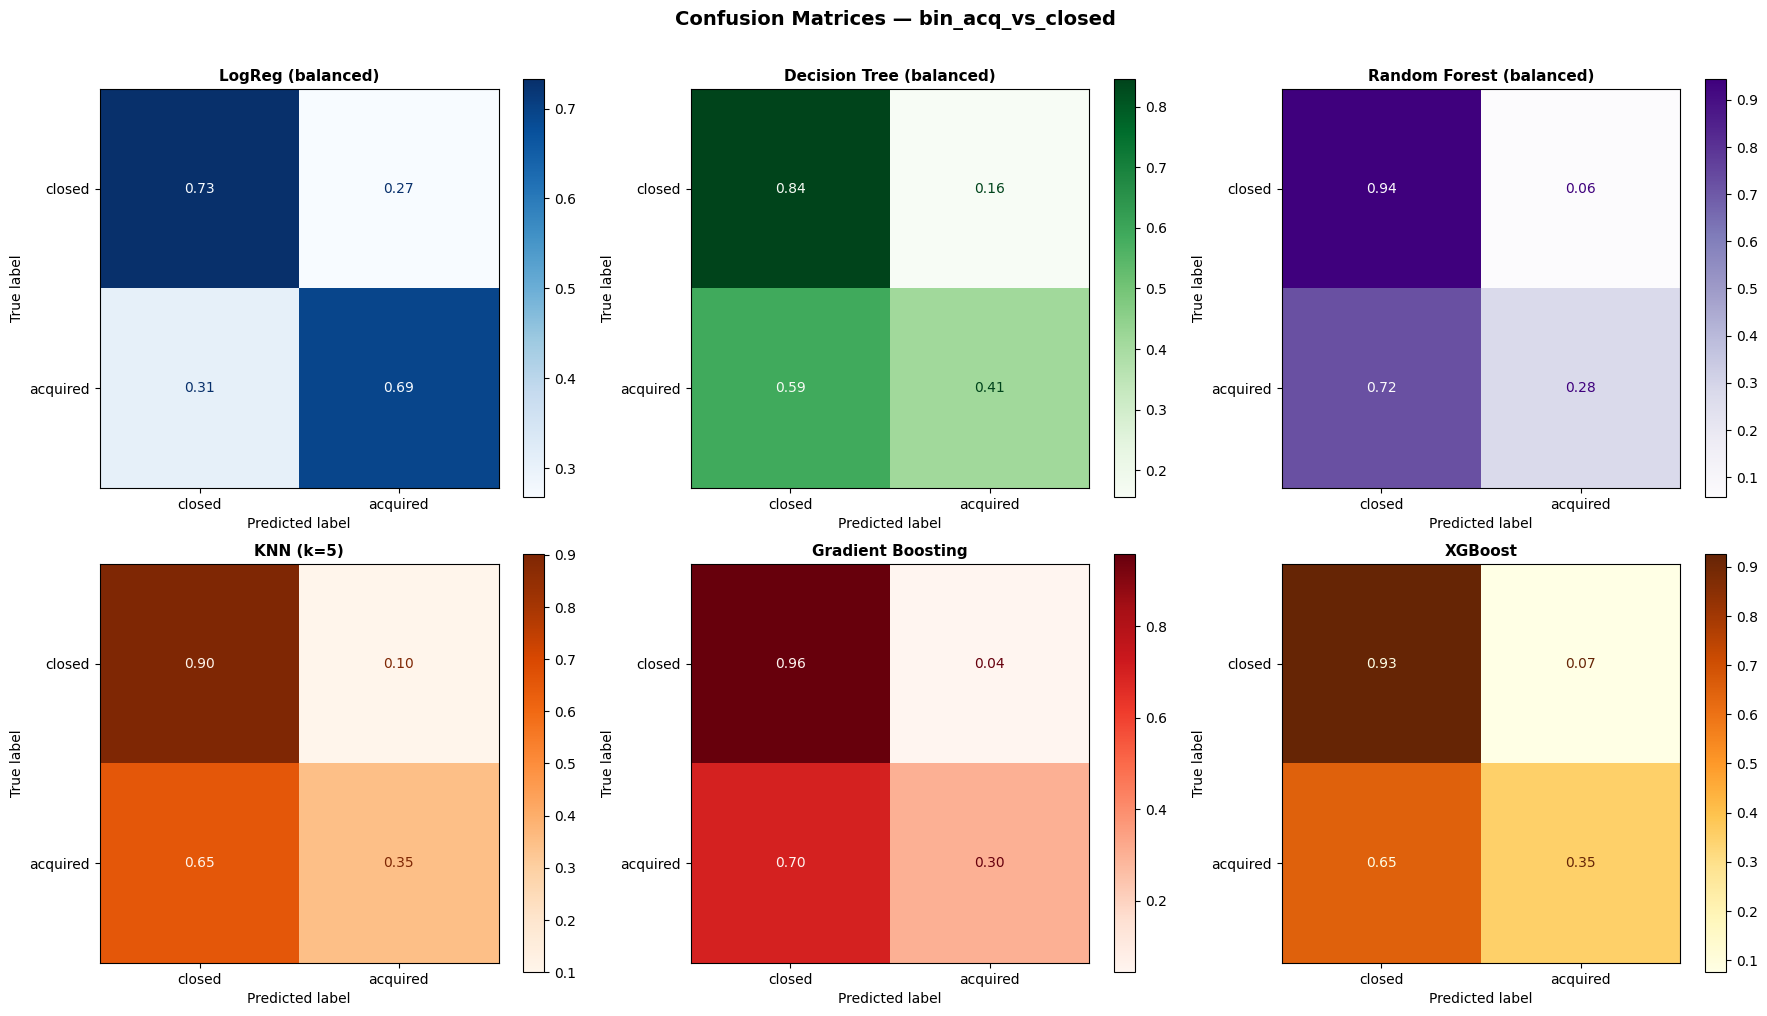


  TARGET: multiclass  (3-class: closed(0) / operating(1) / acquired(2))

  🔹 LogReg (balanced) ... Acc=0.5174  F1w=0.5513  F1m=0.4351  ROC=0.6474

  🔹 Decision Tree (balanced) ... Acc=0.5646  F1w=0.5682  F1m=0.4058  ROC=0.5456

  🔹 Random Forest (balanced) ... Acc=0.6653  F1w=0.6086  F1m=0.3955  ROC=0.6292

  🔹 KNN (k=5) ... Acc=0.6318  F1w=0.6009  F1m=0.3943  ROC=0.5902

  🔹 Gradient Boosting ... Acc=0.6840  F1w=0.5874  F1m=0.3660  ROC=0.6742

  🔹 XGBoost ... Acc=0.6812  F1w=0.6066  F1m=0.4088  ROC=0.6607

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION REPORTS
──────────────────────────────────────────────────────────────────────

  📋 LogReg (balanced):
              precision    recall  f1-score   support

      closed       0.33      0.39      0.36      2206
   operating       0.79      0.55      0.65      5873
    acquired       0.20      0.66      0.30       564

    accuracy                           0.52      8643
   macro avg       0.44

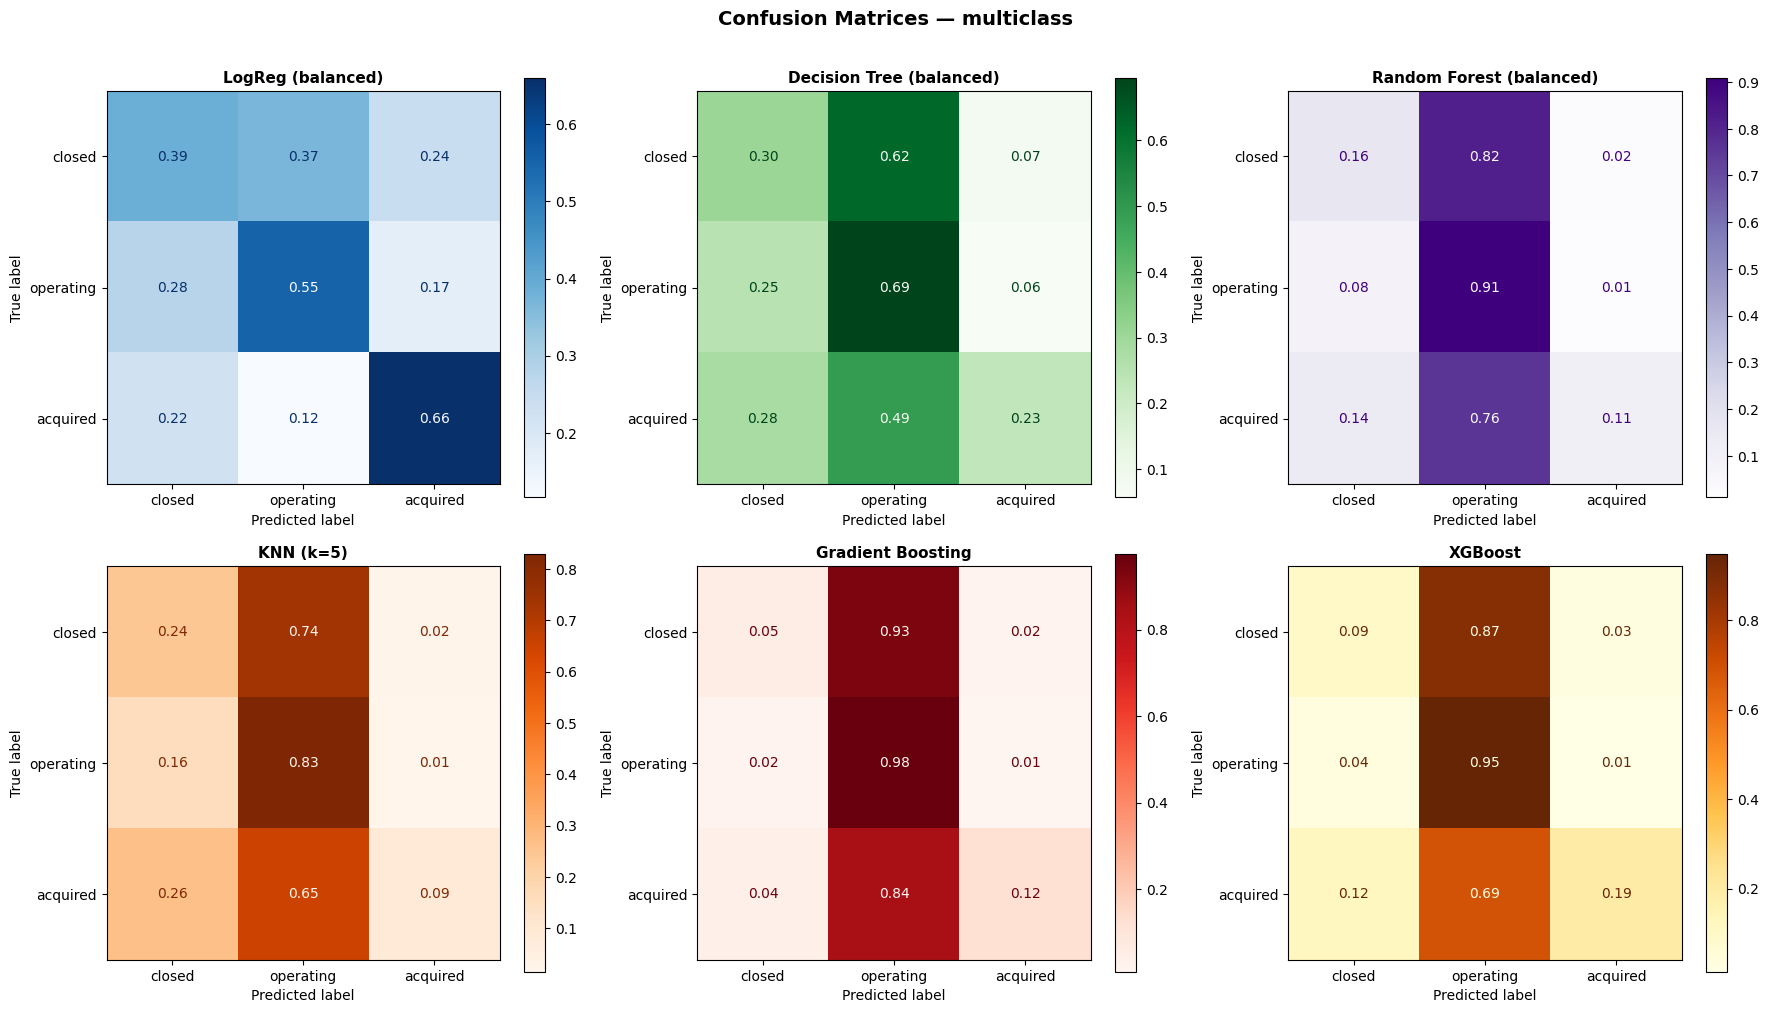


  TARGET: target_bin_refined  (Binary: (acquired+operating) vs closed but refined with business logic)

  🔹 LogReg (balanced) ... Acc=0.5645  F1w=0.5924  F1m=0.5342  ROC=0.6155

  🔹 Decision Tree (balanced) ... Acc=0.6278  F1w=0.6315  F1m=0.5204  ROC=0.5204

  🔹 Random Forest (balanced) ... Acc=0.7199  F1w=0.6679  F1m=0.5119  ROC=0.5766

  🔹 KNN (k=5) ... Acc=0.7000  F1w=0.6668  F1m=0.5265  ROC=0.5561

  🔹 Gradient Boosting ... Acc=0.7448  F1w=0.6428  F1m=0.4411  ROC=0.6280

  🔹 XGBoost ... Acc=0.7353  F1w=0.6535  F1m=0.4700  ROC=0.6044

──────────────────────────────────────────────────────────────────────
  CLASSIFICATION REPORTS
──────────────────────────────────────────────────────────────────────

  📋 LogReg (balanced):
              precision    recall  f1-score   support

      closed       0.32      0.61      0.42      2206
    survived       0.80      0.55      0.65      6437

    accuracy                           0.56      8643
   macro avg       0.56      0.58      0.53   

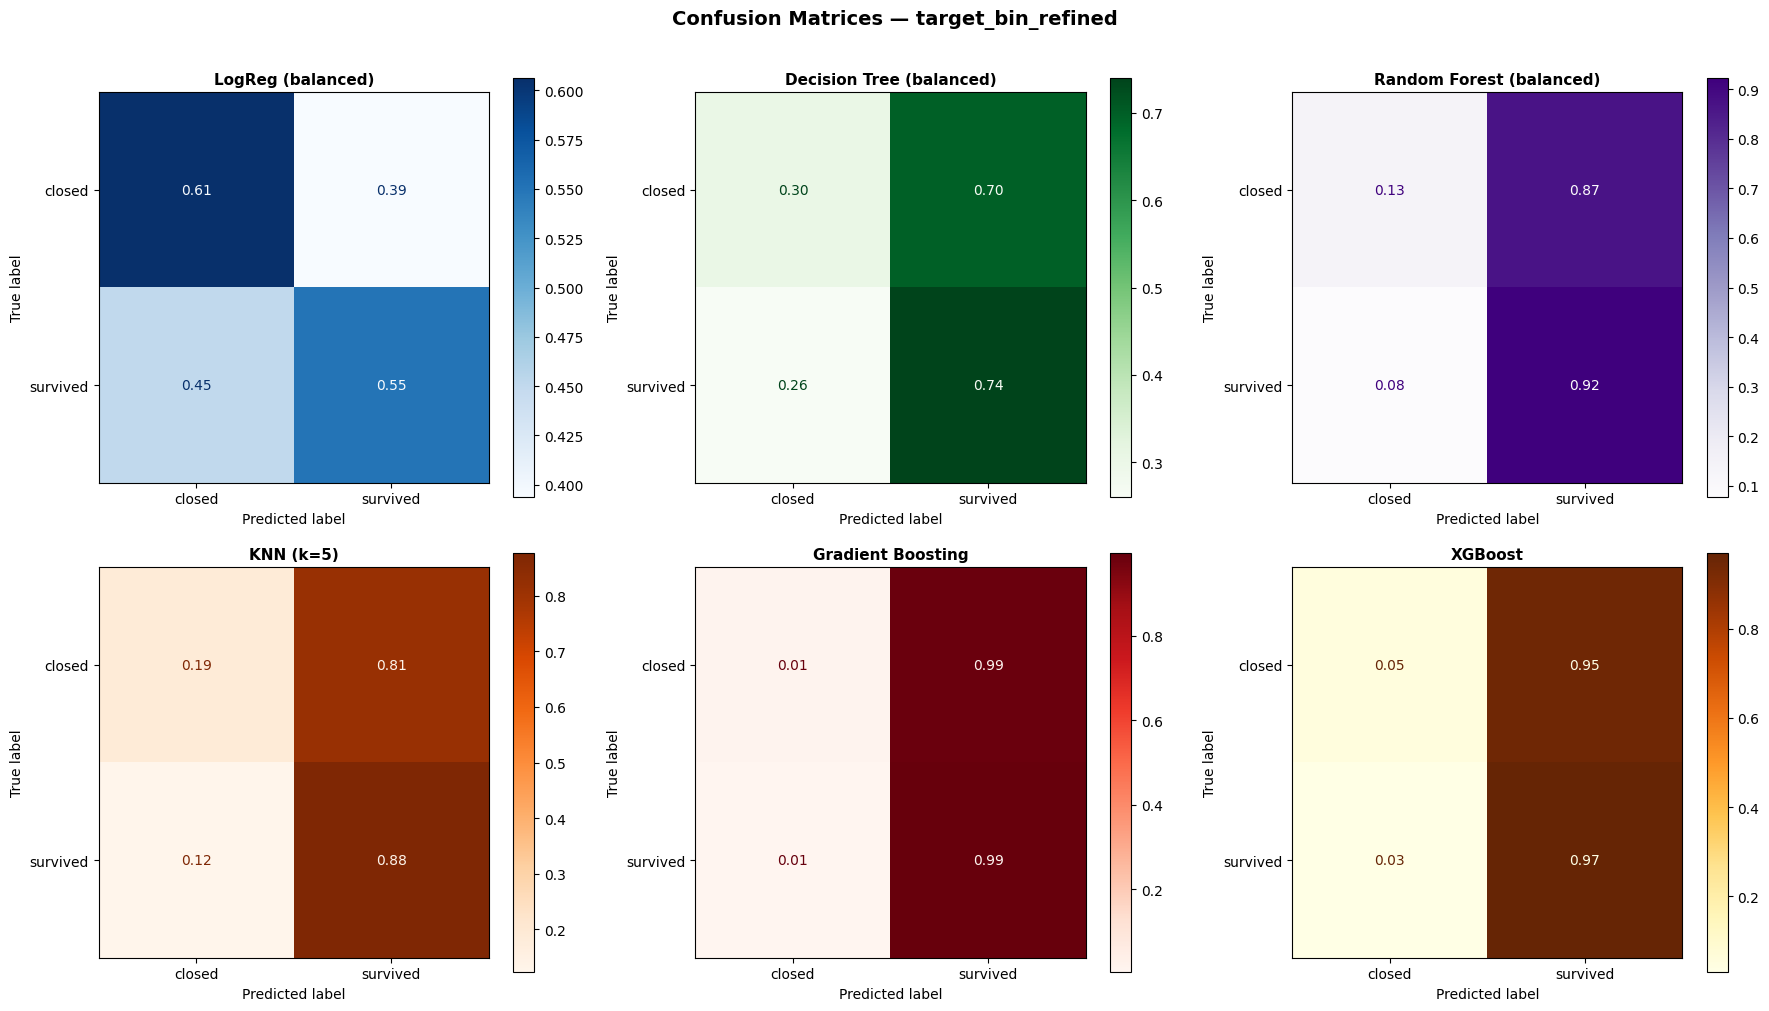

In [7]:
# ## 7 · Training Loop — 3 Targets × 6 Models

results = []

for var_name, split in splits.items():
    print(f'\n{"="*70}')
    print(f'  TARGET: {var_name}  ({TARGETS[var_name]["desc"]})')
    print(f'{"="*70}')

    X_train, X_test = split['X_train'], split['X_test']
    y_train, y_test = split['y_train'], split['y_test']
    n_classes = split['n_classes']
    label_names = split['label_names']

    # Preprocess
    X_train_pp = preprocessor.fit_transform(X_train)
    X_test_pp = preprocessor.transform(X_test)

    models = get_models()
    predictions = {}

    for model_name, model in models.items():
        print(f'\n  🔹 {model_name} ...', end=' ')
        model.fit(X_train_pp, y_train)
        y_pred, y_proba, metrics = evaluate_model(model, X_test_pp, y_test, n_classes)
        predictions[model_name] = y_pred
        results.append({'target': var_name, 'model': model_name, **metrics})

        print(f'Acc={metrics["accuracy"]:.4f}  F1w={metrics["f1_weighted"]:.4f}  '
              f'F1m={metrics["f1_macro"]:.4f}  ROC={metrics["roc_auc"]:.4f}')

    # ── Classification Reports ───────────────────────────────────
    print(f'\n{"─"*70}')
    print(f'  CLASSIFICATION REPORTS')
    print(f'{"─"*70}')
    for model_name, y_pred in predictions.items():
        print(f'\n  📋 {model_name}:')
        print(classification_report(y_test, y_pred, target_names=label_names))

    # ── Confusion Matrices (2×3 grid) ────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes_flat = axes.flatten()
    cmaps = ['Blues', 'Greens', 'Purples', 'Oranges', 'Reds', 'YlOrBr']

    for ax, (model_name, y_pred), cmap in zip(axes_flat, predictions.items(), cmaps):
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, display_labels=label_names,
            ax=ax, cmap=cmap, normalize='true', values_format='.2f'
        )
        ax.set_title(model_name, fontweight='bold', fontsize=11)

    plt.suptitle(f'Confusion Matrices — {var_name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

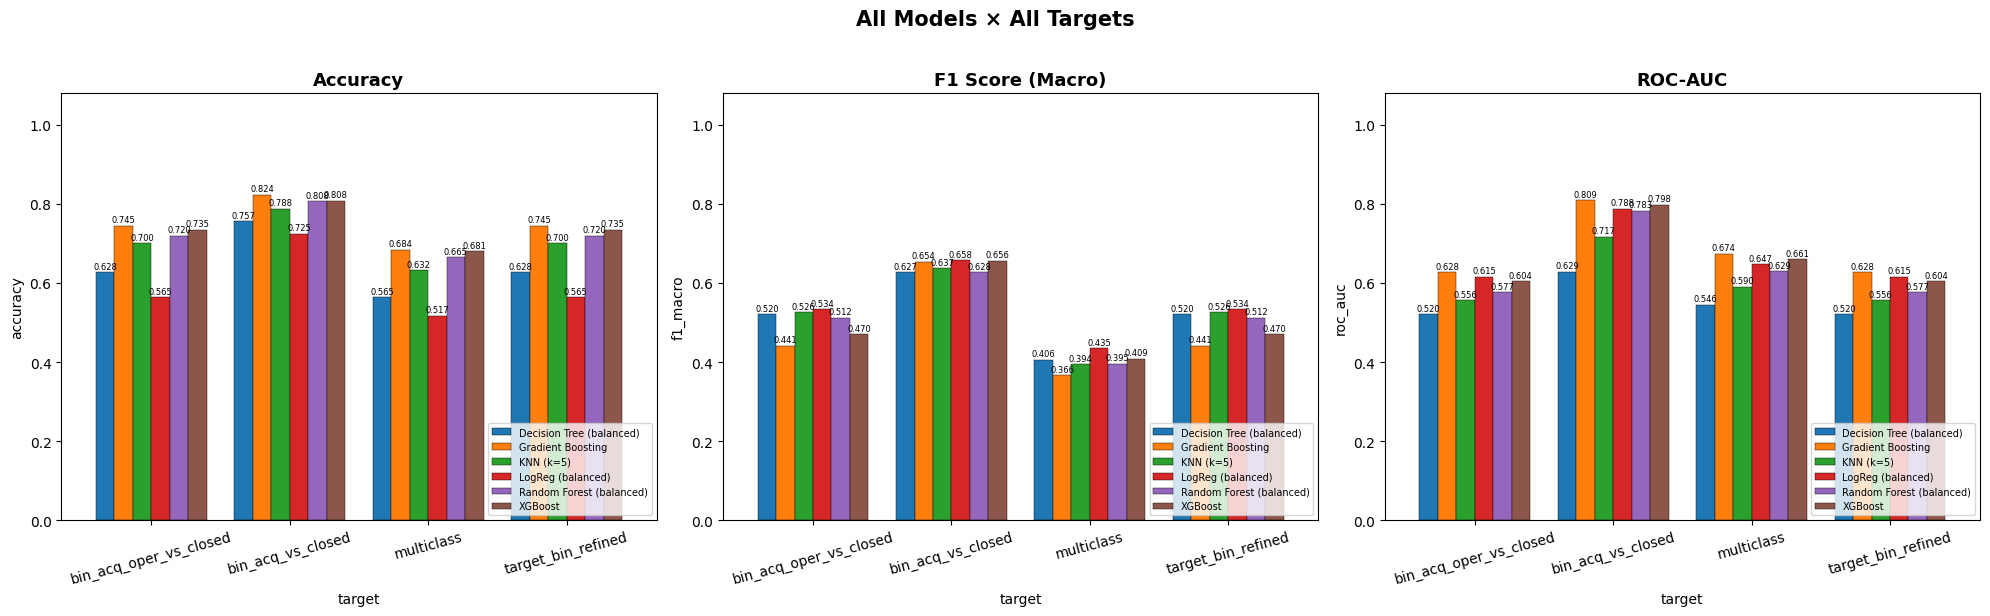

In [8]:
# ## 8 · Results Comparison

#
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['target', 'f1_macro'], ascending=[True, False]).reset_index(drop=True)

styled = results_df.style.format({
    'accuracy': '{:.4f}', 'f1_weighted': '{:.4f}',
    'f1_macro': '{:.4f}', 'roc_auc': '{:.4f}'
}).background_gradient(subset=['f1_macro', 'roc_auc'], cmap='Greens')

styled

#
# Bar chart comparison — one chart per metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics_plot = ['accuracy', 'f1_macro', 'roc_auc']
titles_plot = ['Accuracy', 'F1 Score (Macro)', 'ROC-AUC']

for ax, metric, title in zip(axes, metrics_plot, titles_plot):
    pivot = results_df.pivot(index='target', columns='model', values=metric)
    pivot.plot.bar(ax=ax, rot=15, edgecolor='black', linewidth=0.3, width=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=7, loc='lower right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=6, padding=1)

plt.suptitle('All Models × All Targets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ## 9 · Best Model per Target

#
print('🏆 Best model per target (by F1 Macro):\n')
for target in results_df['target'].unique():
    subset = results_df[results_df['target'] == target]
    best = subset.loc[subset['f1_macro'].idxmax()]
    print(f"  {target:35s} → {best['model']:30s}  F1m={best['f1_macro']:.4f}  ROC={best['roc_auc']:.4f}")

🏆 Best model per target (by F1 Macro):

  bin_acq_oper_vs_closed              → LogReg (balanced)               F1m=0.5342  ROC=0.6155
  bin_acq_vs_closed                   → LogReg (balanced)               F1m=0.6576  ROC=0.7881
  multiclass                          → LogReg (balanced)               F1m=0.4351  ROC=0.6474
  target_bin_refined                  → LogReg (balanced)               F1m=0.5342  ROC=0.6155
